<a href="https://colab.research.google.com/github/umair594/Data-Scientist-projects/blob/main/Customer_Segmentation_Using_K%E2%80%91Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 3: Customer Segmentation Using K‑Means**

**Objective**

>Group customers into meaningful segments using K‑Means clustering based on features like Annual Income and Spending Score.

# **Project Workflow**

**We will:**

>Load & explore data

>Preprocess

>Find optimal K with Elbow Method

>Fit K‑Means

>Visualize segments

>Draw insights

# **IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# **LOAD DATASET**

In [9]:
url = '/content/Mall_Customers.csv'
data = pd.read_csv(url)
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# **Data Inspection**

In [10]:
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


No missing values

Mix of numeric and categorical features

# **Feature Selection**

**For segmentation, we use:**

Annual Income

Spending Score

These two have strong segmentation patterns.

In [11]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# **Optimal K — Elbow Method**

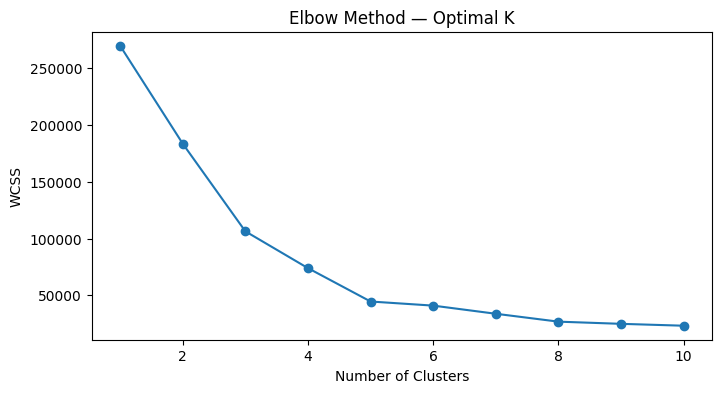

In [12]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method — Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

You’ll typically see a “bend” at K = 5, so we choose 5 clusters.

# **Train K‑Means**

In [13]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X)
data['Cluster'] = clusters
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


# **Visualization of Clusters**

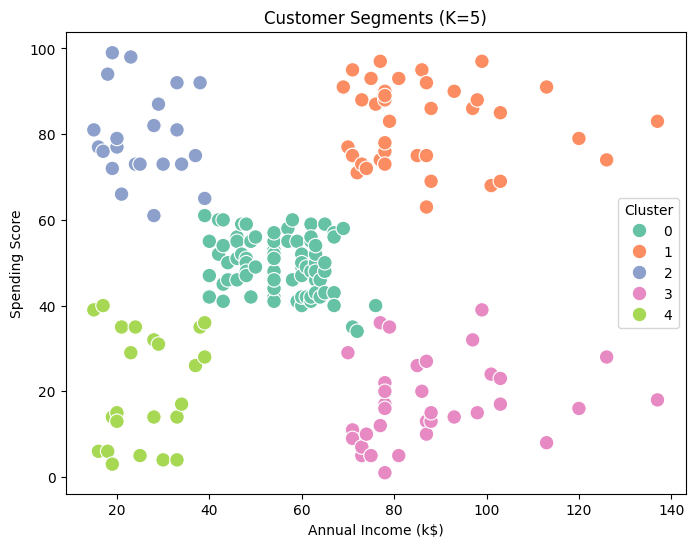

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', data=data, palette='Set2', s=110)
plt.title('Customer Segments (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.show()

# **Optional: Pairplot With Cluster Hue**

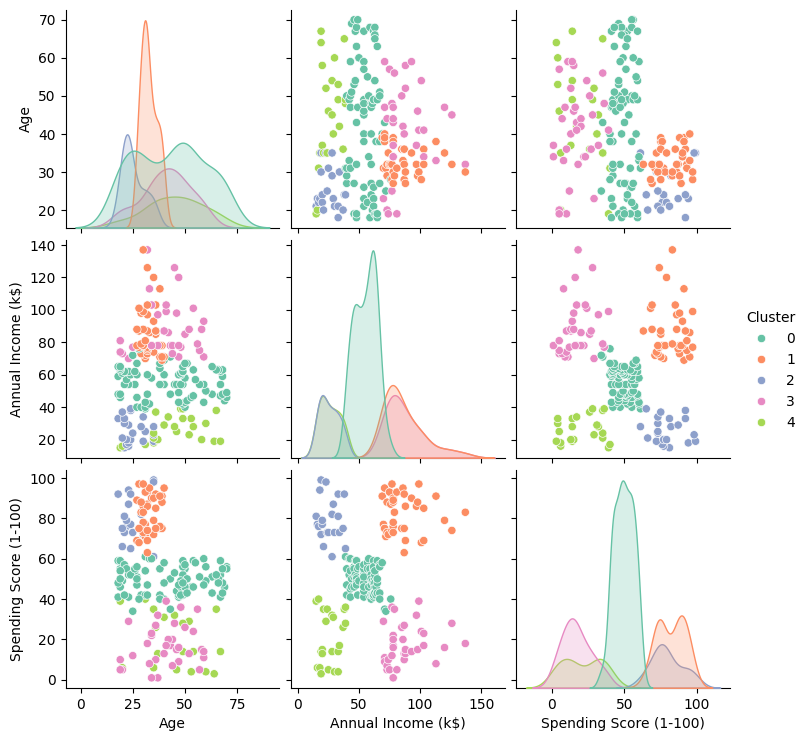

In [15]:
sns.pairplot(data, vars=['Age','Annual Income (k$)','Spending Score (1-100)'],
             hue='Cluster', palette='Set2')
plt.show()

# **Cluster Interpretation**

**Example interpretations:**

| Cluster | Characteristics                  |
| ------- | -------------------------------- |
| 0       | Low Income, Low Spending         |
| 1       | High Income, High Spending       |
| 2       | Medium Income, Moderate Spending |
| 3       | Young Customers, High Score      |
| 4       | High Income, Low Spending        |

You can refine based on mean values.

In [17]:
data.groupby('Cluster').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


# **Business Insights**

>Cluster 1 (High Income, High Spending)
→ Target with premium offers, loyalty programs.

>Cluster 0 (Low Income, Low Spending)
→ Personalized discounts, entry‑level products.

>Cluster 3 (Young, High Score)
→ Fashionable items & social campaigns.

# **Save Segmented Data**

In [18]:
data.to_csv('mall_customers_segmented.csv', index=False)

# **Project Summary**

 >Loaded real customer dataset

 >Preprocessed & scaled features

 >Used Elbow Method to find optimal clusters

 >Applied K‑Means

 >Visualized & interpreted customer segments

 >Generated business insights